In [2]:
pip install pandas numpy scikit-learn imbalanced-learn xgboost matplotlib seaborn joblib

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.3 MB/s eta 0:01:18
   ---------------------------------------- 0.8/101.7 MB 1.5 MB/s eta 0:01:08
    --------------------------------------- 1.3/101.7 MB 1.7 MB/s eta 0:01:00
    --------------------------------------- 1.6/101.7 MB 1.8 MB/s eta 0:00:56
    --------------------------------------- 2.1/101.7 MB 1.9 MB/s eta 0:00:54
   - -------------------------------------- 2.6/101.7 MB 2.0 MB/s eta 0:00:50
   - -------------------------------------- 3.4/101.7 MB 2.2 MB/s eta 0:00:46
   - -------------------------------------- 3.4/101.7 MB 2.2 MB/s eta 0:00:46
   - -------------------------------------- 3.9/101.7 MB 2.0 MB/s eta 0:00:49
   - -------------------------------------- 4.5/101.7 MB 2.0 MB/s eta 0:00:49
   - --

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("C:/Users/rohan/Downloads/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
print(df.shape)
df

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
print(" Churn Distribution")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3) * 100, "% \n")

 Churn Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64 % 



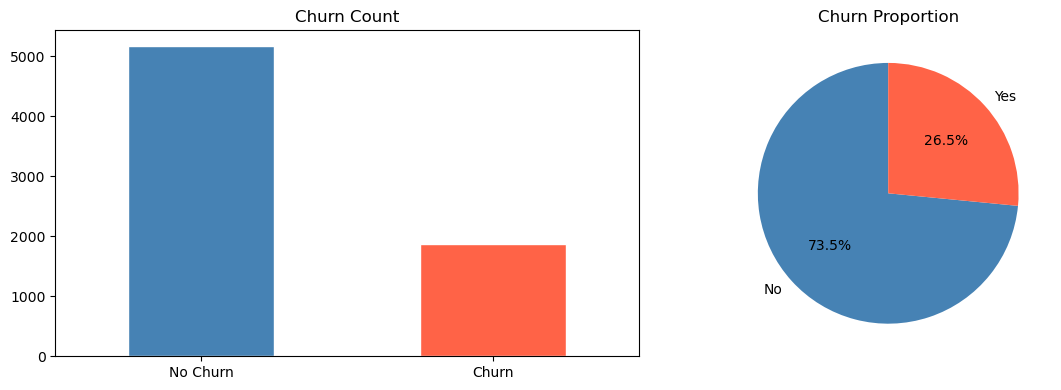

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'],
                                 edgecolor='white')
axes[0].set_title('Churn Count')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)


df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

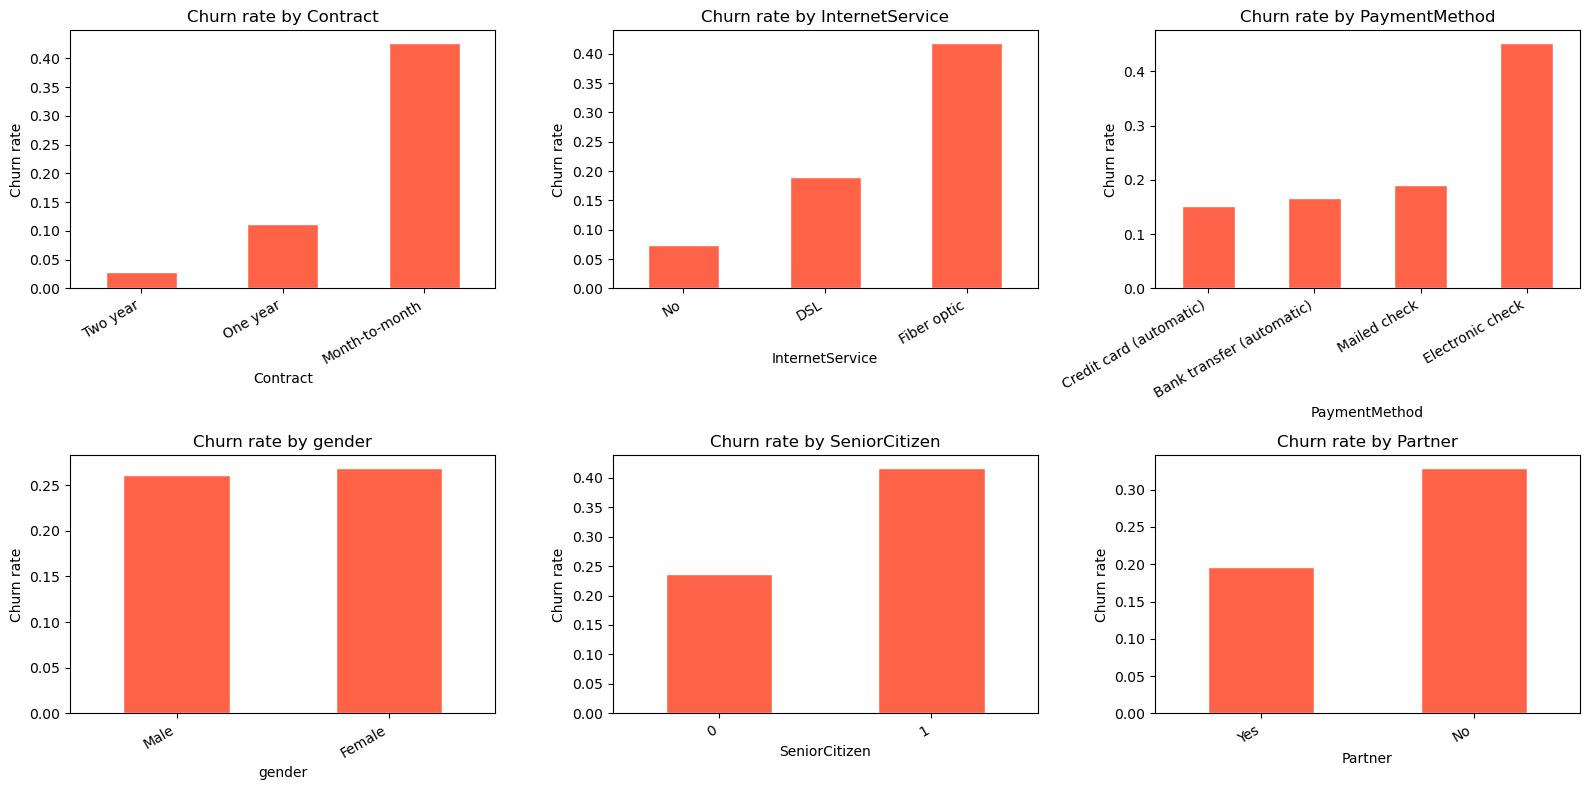

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'gender', 'SeniorCitizen', 'Partner']

for ax, col in zip(axes.flatten(), cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate.sort_values().plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

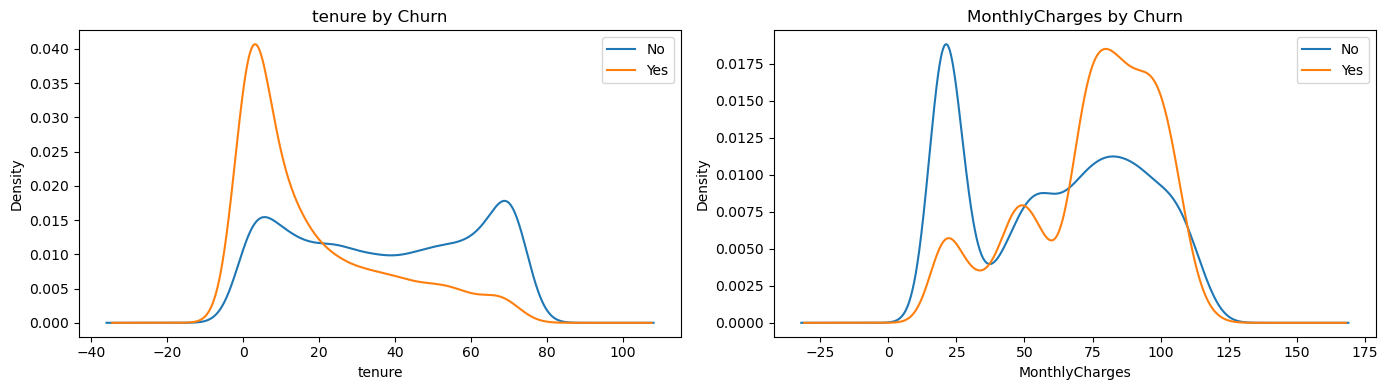

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges']):
    df.groupby('Churn')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [20]:
df_clean = df.copy()

# Drop customer ID
df_clean.drop('customerID', axis=1, inplace=True)

# TotalCharges has some spaces — fix it
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# Encode target
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# Encode all binary/categorical columns with LabelEncoder
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("Shape after preprocessing:", df_clean.shape)
df_clean.head()

Shape after preprocessing: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


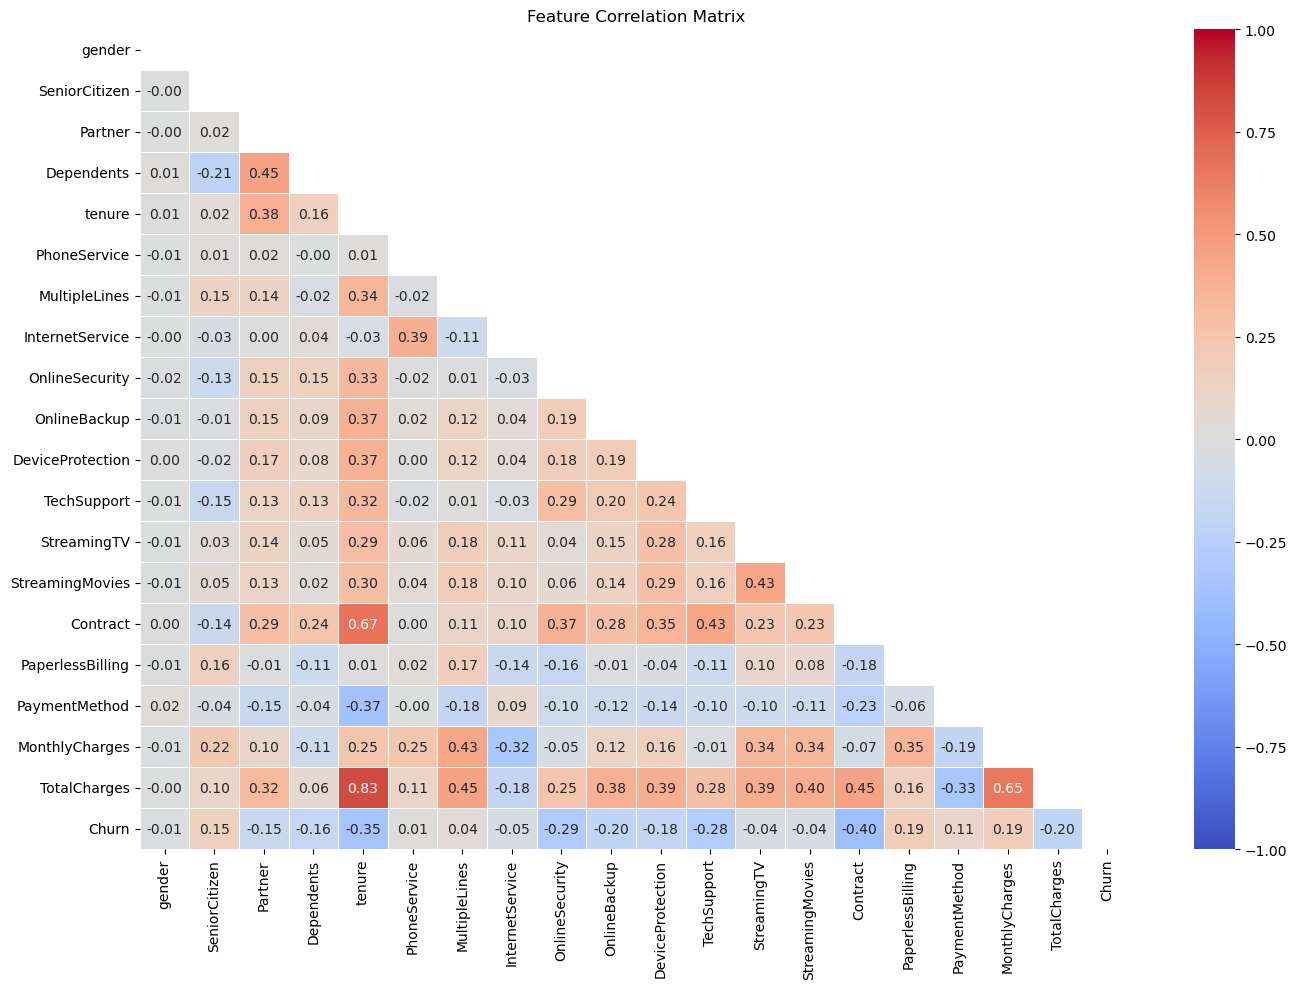

In [21]:
plt.figure(figsize=(14, 10))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [22]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Before SMOTE:", y_train.value_counts().to_dict())

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("After SMOTE :", pd.Series(y_train_sm).value_counts().to_dict())

# Scale features (needed for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE : {0: 4139, 1: 4139}


In [23]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train_sm)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1035
           1       0.52      0.72      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409

ROC-AUC: 0.8223


In [24]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC-AUC: 0.8252


In [25]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1035
           1       0.57      0.61      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC: 0.8302


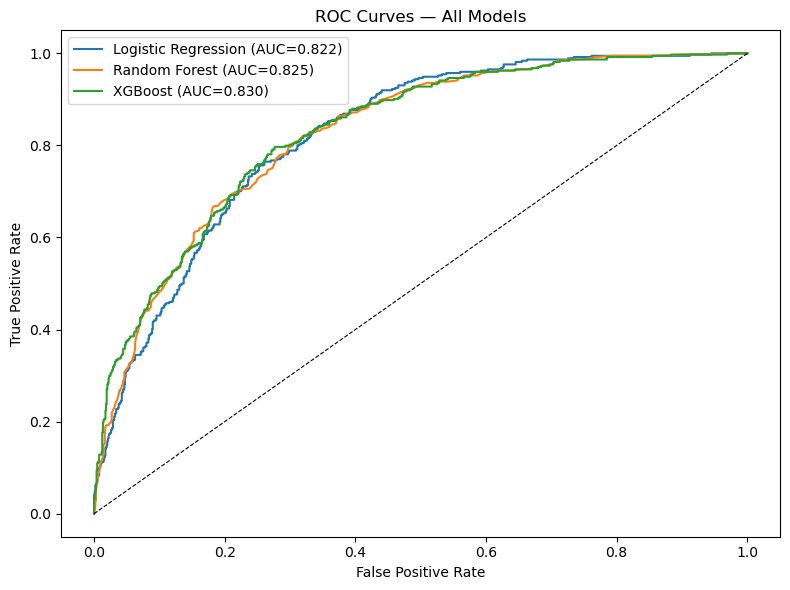

In [26]:
plt.figure(figsize=(8, 6))
for name, prob in [('Logistic Regression', y_prob_lr),
                   ('Random Forest', y_prob_rf),
                   ('XGBoost', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

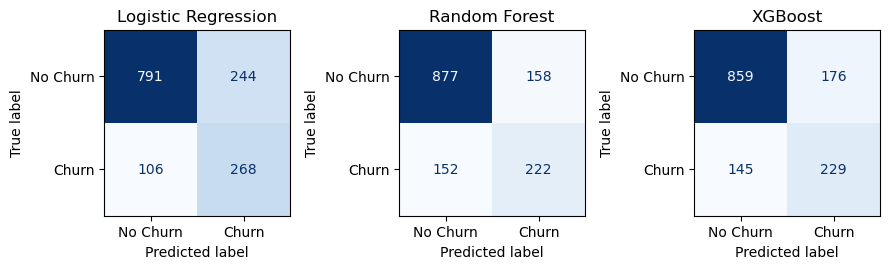

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(9, 4))
for ax, (name, pred) in zip(axes, [
        ('Logistic Regression', y_pred_lr),
        ('Random Forest', y_pred_rf),
        ('XGBoost', y_pred_xgb)]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=['No Churn', 'Churn'],
        colorbar=False, ax=ax, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()

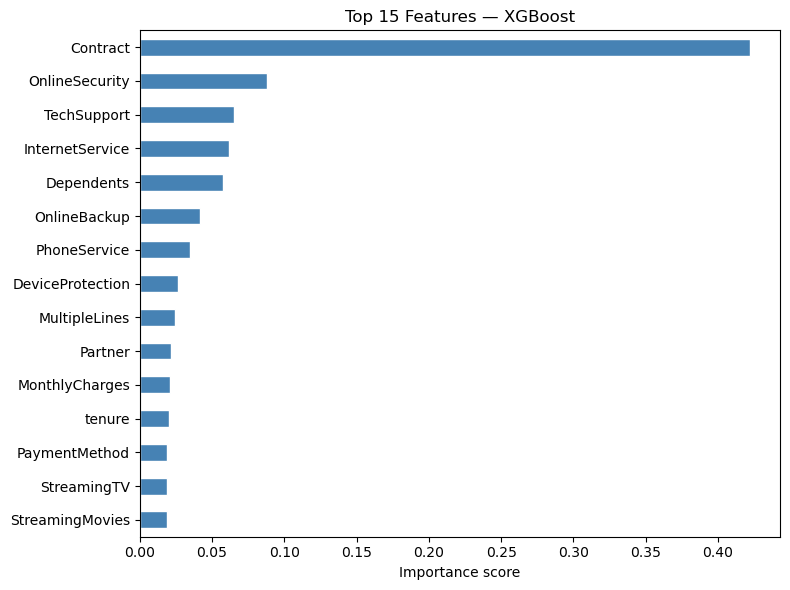

In [29]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).tail(15).plot(
    kind='barh', figsize=(8, 6), color='steelblue', edgecolor='white')
plt.title('Top 15 Features — XGBoost')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

In [33]:
import joblib
joblib.dump(xgb_model, r'C:\Users\rohan\churn_project\churn_model.pkl')
joblib.dump(scaler,    r'C:\Users\rohan\churn_project\scaler.pkl')
print("Saved!")

Saved!
